# Trust Audit Corpus — Validation Experiment

Validates L0/L1/L2/L3 tiering findings across three Claude Code substrates:  
**Skills** (skillhub, claudemarketplaces, etc.), **MCP** (smithery, etc.), **Plugins** (claudemarketplaces).

Reproduces key claims from `FINAL_STATISTICAL_RESULTS.md` and `PAPER_DRAFT_v5.md`.

**Sections:**
1. Setup & Imports  
2. Data Loading  
3. Dataset Overview  
4. Consensus Label Construction (2-of-3 majority)  
5. L0–L3 Distribution & Wilson CIs  
6. Defender Gold Recall  
7. Heuristic Analysis  
8. Cross-Substrate Statistical Tests  
9. Trust Signal Correlations  
10. Cross-Dataset Integrity Check  
11. Visualizations  
12. Findings Summary

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations

# Wilson score interval (two-sided, 95%)
def wilson_ci(k, n, z=1.96):
    """Returns (proportion, lower, upper) Wilson 95% CI."""
    if n == 0:
        return (0.0, 0.0, 0.0)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = (z / denom) * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return (p, max(0, center - margin), min(1, center + margin))

SEVERITY_ORDER = ['L0', 'L1', 'L2', 'L3']
SEVERITY_INT   = {'L0': 0, 'L1': 1, 'L2': 2, 'L3': 3}
SUBSTRATES     = ['skills', 'mcp', 'plugins']
MODELS         = ['debertav3base', 'modernbertbase', 'distilbertbaseuncased']

CORPUS_ROOT = Path('/Users/johnnydao/Documents/School/ASSET LAB/trust_audit_corpus')
RUNS_DIR    = CORPUS_ROOT / 'classifier_runs'
LAB_DIR     = CORPUS_ROOT / 'from_lab_pc' / 'classifier_csvs'

print('Libraries loaded.')
print(f'Corpus root: {CORPUS_ROOT}')
print(f'classifier_runs exists: {RUNS_DIR.exists()}')
print(f'from_lab_pc csvs exists: {LAB_DIR.exists()}')

Libraries loaded.
Corpus root: /Users/johnnydao/Documents/School/ASSET LAB/trust_audit_corpus
classifier_runs exists: True
from_lab_pc csvs exists: True


## 2. Data Loading

In [2]:
# --- Distilled student model CSVs (canonical full-corpus labels) ---
# schema: slug, source, substrate, severity, severity_prob,
#         prompt_injection_prob, malicious_code_prob,
#         secret_exposure_prob, untrusted_fetch_prob,
#         content_len, defender_positive

distilled_ts = '20260422'
distilled_time = {'debertav3base': '1814', 'modernbertbase': '1858',
                  'distilbertbaseuncased': '1801'}

dfs = {}  # dfs[substrate][model] = DataFrame
for sub in SUBSTRATES:
    dfs[sub] = {}
    for model in MODELS:
        fname = f'{sub}_distilled_{model}_{distilled_ts}_{distilled_time[model]}.csv'
        path  = RUNS_DIR / fname
        df = pd.read_csv(path)
        df['severity'] = df['severity'].str.upper().str.strip()
        df['defender_positive'] = df['defender_positive'].astype(str).str.upper() == 'TRUE'
        dfs[sub][model] = df
        print(f'  {sub}/{model}: {len(df):,} rows, severity vals: {sorted(df["severity"].unique())}')

  skills/debertav3base: 97,544 rows, severity vals: ['L0', 'L1', 'L2', 'L3']
  skills/modernbertbase: 97,544 rows, severity vals: ['L0', 'L1', 'L2', 'L3']
  skills/distilbertbaseuncased: 97,544 rows, severity vals: ['L0', 'L1', 'L2', 'L3']
  mcp/debertav3base: 24,855 rows, severity vals: ['L0', 'L1', 'L2', 'L3']
  mcp/modernbertbase: 24,855 rows, severity vals: ['L0', 'L1', 'L2', 'L3']
  mcp/distilbertbaseuncased: 24,855 rows, severity vals: ['L0', 'L1', 'L2', 'L3']
  plugins/debertav3base: 5,755 rows, severity vals: ['L0', 'L1', 'L2', 'L3']
  plugins/modernbertbase: 5,755 rows, severity vals: ['L0', 'L1', 'L2', 'L3']
  plugins/distilbertbaseuncased: 5,755 rows, severity vals: ['L0', 'L1', 'L2', 'L3']


In [3]:
# --- Heuristic CSVs (canonical run: 0748) ---
# schema: slug, source, substrate, heuristic_hit_count, heuristic_flags,
#         patterns, content_len, stars, installs, official_badge, defender_positive

heuristic_time = '0748'
heuristic = {}
for sub in SUBSTRATES:
    fname = f'{sub}_heuristic_20260421_{heuristic_time}.csv'
    path  = RUNS_DIR / fname
    df = pd.read_csv(path)
    df['defender_positive'] = df['defender_positive'].astype(str).str.upper() == 'TRUE'
    df['any_flag'] = df['heuristic_hit_count'] > 0
    heuristic[sub] = df
    flagged = df['any_flag'].sum()
    print(f'  {sub} heuristic: {len(df):,} rows, flagged: {flagged:,} ({flagged/len(df)*100:.2f}%)')

  skills heuristic: 93,735 rows, flagged: 7,509 (8.01%)
  mcp heuristic: 21,355 rows, flagged: 0 (0.00%)
  plugins heuristic: 2,629 rows, flagged: 0 (0.00%)


In [4]:
# --- LLM labels CSVs (Gemma-labeled sample, used for teacher signal) ---
# schema: slug, source, substrate, severity, prompt_injection, malicious_code,
#         secret_exposure, untrusted_fetch, heuristic_hit_count, heuristic_flags,
#         rationale, classifier_error, content_len, elapsed_s, stars, installs,
#         official_badge, defender_positive

labels_files = {
    'skills':  ['skills_labels_20260421_0123.csv',
                'skills_labels_20260421_0157.csv',
                'skills_labels_20260421_0248.csv'],
    'mcp':     ['mcp_labels_20260421_0407.csv'],
    'plugins': ['plugins_labels_20260421_0459.csv'],
}

labels = {}
for sub, files in labels_files.items():
    frames = []
    for f in files:
        path = RUNS_DIR / f
        if path.exists():
            frames.append(pd.read_csv(path))
    combined = pd.concat(frames, ignore_index=True).drop_duplicates(subset='slug')
    combined['severity'] = combined['severity'].str.upper().str.strip()
    combined['defender_positive'] = combined['defender_positive'].astype(str).str.upper() == 'TRUE'
    labels[sub] = combined
    print(f'  {sub} labels: {len(combined):,} rows (deduped), defender gold: {combined["defender_positive"].sum()}')

  skills labels: 403 rows (deduped), defender gold: 51
  mcp labels: 200 rows (deduped), defender gold: 0
  plugins labels: 200 rows (deduped), defender gold: 0


In [5]:
# --- from_lab_pc distilled CSVs (cross-validate against local) ---
lab_dfs = {}
for sub in SUBSTRATES:
    lab_dfs[sub] = {}
    for model in MODELS:
        fname = f'{sub}_distilled_{model}_{distilled_ts}_{distilled_time[model]}.csv'
        path  = LAB_DIR / fname
        if path.exists():
            df = pd.read_csv(path)
            df['severity'] = df['severity'].str.upper().str.strip()
            lab_dfs[sub][model] = df
            print(f'  lab/{sub}/{model}: {len(df):,} rows')
        else:
            print(f'  MISSING: lab/{sub}/{model}')

  lab/skills/debertav3base: 97,544 rows
  lab/skills/modernbertbase: 97,544 rows
  lab/skills/distilbertbaseuncased: 97,544 rows
  lab/mcp/debertav3base: 24,855 rows
  lab/mcp/modernbertbase: 24,855 rows
  lab/mcp/distilbertbaseuncased: 24,855 rows
  lab/plugins/debertav3base: 5,755 rows
  lab/plugins/modernbertbase: 5,755 rows
  lab/plugins/distilbertbaseuncased: 5,755 rows


## 3. Dataset Overview

In [6]:
print('=== Dataset size validation ===')
print('Paper reports: skills 97,544 | mcp 24,855 | plugins 5,755')
print()

ref_model = 'debertav3base'
for sub in SUBSTRATES:
    n = len(dfs[sub][ref_model])
    n_defender = dfs[sub][ref_model]['defender_positive'].sum()
    print(f'{sub:10s}: {n:>7,} items | {n_defender} defender-gold')

print()
print('--- Source breakdown (skills) ---')
dfs['skills'][ref_model]['source'].value_counts().to_frame('count').assign(
    pct=lambda d: (d['count'] / d['count'].sum() * 100).round(2)
)

=== Dataset size validation ===
Paper reports: skills 97,544 | mcp 24,855 | plugins 5,755

skills    :  97,544 items | 51 defender-gold
mcp       :  24,855 items | 0 defender-gold
plugins   :   5,755 items | 0 defender-gold

--- Source breakdown (skills) ---


,count,pct
source,,
skillhub,87074,89.27
claudemarketplaces,4242,4.35
github_skills,3839,3.94
skillsmp,1200,1.23
skills.sh,683,0.70
lobehub_agents,505,0.52
skillsmp_hydrated,1,0.00


In [7]:
# Check for duplicate slugs within each substrate/model
print('=== Duplicate slug check ===')
for sub in SUBSTRATES:
    for model in MODELS:
        df = dfs[sub][model]
        dupes = df.duplicated(subset='slug').sum()
        if dupes > 0:
            print(f'  WARNING {sub}/{model}: {dupes} duplicate slugs')
        else:
            print(f'  OK {sub}/{model}: no duplicates')

=== Duplicate slug check ===
  WARNING skills/debertav3base: 1 duplicate slugs
  WARNING skills/modernbertbase: 1 duplicate slugs
  WARNING skills/distilbertbaseuncased: 1 duplicate slugs
  WARNING mcp/debertav3base: 167 duplicate slugs
  WARNING mcp/modernbertbase: 167 duplicate slugs
  WARNING mcp/distilbertbaseuncased: 167 duplicate slugs
  OK plugins/debertav3base: no duplicates
  OK plugins/modernbertbase: no duplicates
  OK plugins/distilbertbaseuncased: no duplicates


In [8]:
# Null / missing severity check
print('=== Null severity check ===')
for sub in SUBSTRATES:
    for model in MODELS:
        df = dfs[sub][model]
        nulls = df['severity'].isnull().sum()
        bad   = df.loc[~df['severity'].isnull() & ~df['severity'].isin(SEVERITY_ORDER), 'severity'].unique()
        status = 'OK' if nulls == 0 and len(bad) == 0 else f'WARN nulls={nulls} bad_vals={bad}'
        print(f'  {sub}/{model}: {status}')

=== Null severity check ===
  skills/debertav3base: OK
  skills/modernbertbase: OK
  skills/distilbertbaseuncased: OK
  mcp/debertav3base: OK
  mcp/modernbertbase: OK
  mcp/distilbertbaseuncased: OK
  plugins/debertav3base: OK
  plugins/modernbertbase: OK
  plugins/distilbertbaseuncased: OK


## 4. Consensus Label Construction (2-of-3 Majority Vote)

In [9]:
def build_consensus(dfs_sub):
    """
    Merge three student model DataFrames on slug.
    Consensus = 2-of-3 majority vote among severity labels.
    Tie-breaks (all different): use highest severity (conservative).
    Returns merged DataFrame with columns: slug, sev_A, sev_B, sev_C, consensus_severity.
    """
    m_names = list(dfs_sub.keys())
    base = dfs_sub[m_names[0]][['slug', 'source', 'substrate', 'severity',
                                  'content_len', 'defender_positive']].copy()
    base = base.rename(columns={'severity': f'sev_{m_names[0]}'})

    for mn in m_names[1:]:
        other = dfs_sub[mn][['slug', 'severity']].rename(columns={'severity': f'sev_{mn}'})
        base  = base.merge(other, on='slug', how='inner')

    sev_cols = [f'sev_{mn}' for mn in m_names]

    def majority(row):
        votes = [row[c] for c in sev_cols]
        from collections import Counter
        cnt = Counter(votes)
        top = cnt.most_common(1)[0]
        if top[1] >= 2:
            return top[0]
        # All different — pick highest severity (conservative)
        return max(votes, key=lambda v: SEVERITY_INT[v])

    base['consensus_severity'] = base.apply(majority, axis=1)
    return base


consensus = {}
for sub in SUBSTRATES:
    df_con = build_consensus(dfs[sub])
    consensus[sub] = df_con
    n_L3 = (df_con['consensus_severity'] == 'L3').sum()
    total = len(df_con)
    print(f'{sub}: {total:,} consensus items | L3 = {n_L3:,} ({n_L3/total*100:.2f}%)')

skills: 97,550 consensus items | L3 = 2,277 (2.33%)
mcp: 25,869 consensus items | L3 = 241 (0.93%)
plugins: 5,755 consensus items | L3 = 270 (4.69%)


In [10]:
# Validate against paper headline numbers
# Paper: skills 1,637 L3 | mcp 164 L3 | plugins 240 L3
print('=== L3 count validation vs. paper ===')
paper_L3 = {'skills': 1637, 'mcp': 164, 'plugins': 240}
for sub in SUBSTRATES:
    n_L3 = (consensus[sub]['consensus_severity'] == 'L3').sum()
    expected = paper_L3[sub]
    delta = n_L3 - expected
    match = 'MATCH' if delta == 0 else f'DIFF {delta:+d}'
    print(f'  {sub}: computed {n_L3:,} | paper {expected:,} | {match}')

=== L3 count validation vs. paper ===
  skills: computed 2,277 | paper 1,637 | DIFF +640
  mcp: computed 241 | paper 164 | DIFF +77
  plugins: computed 270 | paper 240 | DIFF +30


In [11]:
# Per-model agreement rate across substrates
# Paper: skills 60.9% | mcp 67.6% | plugins 81.5%
print('=== Inter-model agreement (all 3 students agree) ===')
paper_agree = {'skills': 60.9, 'mcp': 67.6, 'plugins': 81.5}
for sub in SUBSTRATES:
    df = consensus[sub]
    m_names = list(dfs[sub].keys())
    sev_cols = [f'sev_{mn}' for mn in m_names]
    agree = df.apply(lambda r: len(set(r[c] for c in sev_cols)) == 1, axis=1).mean() * 100
    expected = paper_agree[sub]
    print(f'  {sub}: {agree:.1f}% agree | paper {expected:.1f}%')

=== Inter-model agreement (all 3 students agree) ===
  skills: 60.9% agree | paper 60.9%
  mcp: 66.8% agree | paper 67.6%
  plugins: 81.5% agree | paper 81.5%


## 5. L0–L3 Distribution & Wilson CIs

In [12]:
dist_results = {}

for sub in SUBSTRATES:
    df  = consensus[sub]
    n   = len(df)
    vc  = df['consensus_severity'].value_counts()
    rows = []
    for tier in SEVERITY_ORDER:
        k = vc.get(tier, 0)
        p, lo, hi = wilson_ci(k, n)
        rows.append({'tier': tier, 'count': k, 'pct': p*100,
                     'ci_lo': lo*100, 'ci_hi': hi*100})
    dist_results[sub] = pd.DataFrame(rows).set_index('tier')

print('=== L0-L3 Distribution with Wilson 95% CIs ===')
for sub in SUBSTRATES:
    print(f'\n--- {sub} (N={len(consensus[sub]):,}) ---')
    print(dist_results[sub].to_string(float_format=lambda x: f'{x:.3f}'))

=== L0-L3 Distribution with Wilson 95% CIs ===

--- skills (N=97,550) ---
      count    pct  ci_lo  ci_hi
tier                            
L0    29897 30.648 30.359 30.938
L1    49979 51.234 50.921 51.548
L2    15397 15.784 15.556 16.014
L3     2277  2.334  2.241  2.431

--- mcp (N=25,869) ---
      count    pct  ci_lo  ci_hi
tier                            
L0     4424 17.102 16.648 17.565
L1    17927 69.299 68.734 69.858
L2     3277 12.668 12.268 13.079
L3      241  0.932  0.822  1.056

--- plugins (N=5,755) ---
      count    pct  ci_lo  ci_hi
tier                            
L0      533  9.262  8.539 10.038
L1     4556 79.166 78.097 80.196
L2      396  6.881  6.255  7.564
L3      270  4.692  4.175  5.269


In [13]:
# Cross-reference specific paper claims:
# skills L3: 1.96% CI [1.88, 2.05]
# mcp   L3: 0.66% CI [0.57, 0.77]
# plugins L3: 4.17% CI [3.68, 4.72]
print('=== L3 prevalence vs. paper CIs ===')
paper_ci = {
    'skills':  (1.96, 1.88, 2.05),
    'mcp':     (0.66, 0.57, 0.77),
    'plugins': (4.17, 3.68, 4.72),
}
for sub in SUBSTRATES:
    row  = dist_results[sub].loc['L3']
    p_pct, p_lo, p_hi = paper_ci[sub]
    in_ci = p_lo <= row['pct'] <= p_hi
    check = 'IN CI' if in_ci else 'OUTSIDE CI'
    print(f'  {sub}: computed {row["pct"]:.2f}% [{row["ci_lo"]:.2f},{row["ci_hi"]:.2f}] | '
          f'paper {p_pct}% [{p_lo},{p_hi}] | {check}')

=== L3 prevalence vs. paper CIs ===
  skills: computed 2.33% [2.24,2.43] | paper 1.96% [1.88,2.05] | OUTSIDE CI
  mcp: computed 0.93% [0.82,1.06] | paper 0.66% [0.57,0.77] | OUTSIDE CI
  plugins: computed 4.69% [4.17,5.27] | paper 4.17% [3.68,4.72] | IN CI


## 6. Defender Gold Recall

In [14]:
# Paper: Defender gold = 51 skills items; all classifiers recall 100% at consensus
# DeBERTa-PI: 0%; DeBERTa-distilled: 100%; ModernBERT: 98%; DistilBERT: 100%; ensemble: 100%

print('=== Defender Gold Recall ===')

for sub in SUBSTRATES:
    con_df = consensus[sub]
    gold   = con_df[con_df['defender_positive'] == True]
    if len(gold) == 0:
        print(f'  {sub}: 0 defender-gold items in consensus set')
        continue

    n_gold = len(gold)
    n_L3   = (gold['consensus_severity'] == 'L3').sum()
    recall = n_L3 / n_gold
    print(f'  {sub}: {n_gold} gold items | {n_L3} labeled L3 | recall = {recall:.2%}')

    # Per-model recall
    m_names = list(dfs[sub].keys())
    for mn in m_names:
        sev_col = f'sev_{mn}'
        n_L3_m  = (gold[sev_col] == 'L3').sum()
        r_m     = n_L3_m / n_gold
        print(f'    {mn}: {n_L3_m}/{n_gold} = {r_m:.2%}')

=== Defender Gold Recall ===
  skills: 51 gold items | 51 labeled L3 | recall = 100.00%
    debertav3base: 51/51 = 100.00%
    modernbertbase: 50/51 = 98.04%
    distilbertbaseuncased: 51/51 = 100.00%
  mcp: 0 defender-gold items in consensus set
  plugins: 0 defender-gold items in consensus set


In [15]:
# Signature blindness check:
# Paper claims Defender signature recall on L3 = 3.12% (51 / 1,637)
# i.e., out of all L3 items, only 3.12% are in Defender gold
print('=== Signature Blindness: Defender gold coverage of L3 ===')
for sub in SUBSTRATES:
    con_df = consensus[sub]
    n_L3   = (con_df['consensus_severity'] == 'L3').sum()
    n_gold_in_L3 = ((con_df['consensus_severity'] == 'L3') &
                    (con_df['defender_positive'] == True)).sum()
    if n_L3 > 0:
        coverage = n_gold_in_L3 / n_L3
        print(f'  {sub}: {n_gold_in_L3}/{n_L3} L3 items in Defender gold = {coverage:.2%}')
    else:
        print(f'  {sub}: no L3 items')

=== Signature Blindness: Defender gold coverage of L3 ===
  skills: 51/2277 L3 items in Defender gold = 2.24%
  mcp: 0/241 L3 items in Defender gold = 0.00%
  plugins: 0/270 L3 items in Defender gold = 0.00%


## 7. Heuristic Analysis

In [16]:
# Paper: skills heuristic any-flag = 9.47% (9,238 / 97,544)
print('=== Heuristic Any-Flag Prevalence ===')
paper_heur = {'skills': (9.47, 9238, 97544), 'mcp': None, 'plugins': None}

for sub in SUBSTRATES:
    df  = heuristic[sub]
    n   = len(df)
    k   = df['any_flag'].sum()
    p, lo, hi = wilson_ci(k, n)
    print(f'  {sub}: {k:,}/{n:,} = {p*100:.2f}% [{lo*100:.2f}, {hi*100:.2f}]')
    if paper_heur.get(sub):
        pp, pk, pn = paper_heur[sub]
        print(f'    Paper: {pp}% ({pk}/{pn}) — {'MATCH' if abs(p*100 - pp) < 0.1 else f'DIFF {p*100-pp:+.2f}pp'}')

=== Heuristic Any-Flag Prevalence ===
  skills: 7,509/93,735 = 8.01% [7.84, 8.19]
    Paper: 9.47% (9238/97544) — DIFF -1.46pp
  mcp: 0/21,355 = 0.00% [0.00, 0.02]
  plugins: 0/2,629 = 0.00% [0.00, 0.15]


In [17]:
# Heuristic recall on Defender gold
# Paper: 100% (51/51)
print('=== Heuristic Recall on Defender Gold ===')
for sub in SUBSTRATES:
    df   = heuristic[sub]
    gold = df[df['defender_positive'] == True]
    if len(gold) == 0:
        print(f'  {sub}: 0 defender-gold in heuristic set')
        continue
    caught = gold['any_flag'].sum()
    recall = caught / len(gold)
    print(f'  {sub}: {caught}/{len(gold)} = {recall:.2%}')

=== Heuristic Recall on Defender Gold ===
  skills: 4/51 = 7.84%
  mcp: 0 defender-gold in heuristic set
  plugins: 0 defender-gold in heuristic set


In [18]:
# Flag type breakdown across heuristic
print('=== Heuristic Flag Type Breakdown (skills) ===')
df_h = heuristic['skills']
if 'heuristic_flags' in df_h.columns:
    # flags are comma-separated strings in the column
    from collections import Counter
    flag_counts = Counter()
    for val in df_h['heuristic_flags'].dropna():
        for f in str(val).split(','):
            f = f.strip()
            if f:
                flag_counts[f] += 1
    print(pd.Series(flag_counts, name='count').sort_values(ascending=False).to_frame())
else:
    print('  heuristic_flags column not present')

=== Heuristic Flag Type Breakdown (skills) ===
                  count
untrusted_fetch    3210
malicious_code     2831
secret_exposure    1501
prompt_injection    476


## 8. Cross-Substrate Statistical Tests

In [19]:
# Chi-squared test of independence across substrates on severity distribution
# Paper: p=0 (i.e., p << 0.001), significant differences

print('=== Chi-Squared Test: Severity Distribution Independence Across Substrates ===')
contingency = []
for sub in SUBSTRATES:
    vc = consensus[sub]['consensus_severity'].value_counts()
    row = [vc.get(t, 0) for t in SEVERITY_ORDER]
    contingency.append(row)

ct = np.array(contingency)
chi2, p, dof, expected = chi2_contingency(ct)
print(f'Chi2 statistic : {chi2:.2f}')
print(f'Degrees of freedom: {dof}')
print(f'p-value        : {p:.2e}')
print(f'Significant (p<0.001): {p < 0.001}')

ct_df = pd.DataFrame(contingency, index=SUBSTRATES, columns=SEVERITY_ORDER)
ct_df['N'] = ct_df.sum(axis=1)
print('\nContingency table (raw counts):')
print(ct_df)

=== Chi-Squared Test: Severity Distribution Independence Across Substrates ===
Chi2 statistic : 4605.92
Degrees of freedom: 6
p-value        : 0.00e+00
Significant (p<0.001): True

Contingency table (raw counts):
            L0     L1     L2    L3      N
skills   29897  49979  15397  2277  97550
mcp       4424  17927   3277   241  25869
plugins    533   4556    396   270   5755


In [20]:
# Mann-Whitney U pairwise (ordinal severity: L0=0,L1=1,L2=2,L3=3)
print('=== Mann-Whitney U Pairwise Tests ===')

sev_arrays = {}
for sub in SUBSTRATES:
    sev_arrays[sub] = consensus[sub]['consensus_severity'].map(SEVERITY_INT).values

for sub_a, sub_b in combinations(SUBSTRATES, 2):
    U, p = mannwhitneyu(sev_arrays[sub_a], sev_arrays[sub_b], alternative='two-sided')
    n_a  = len(sev_arrays[sub_a])
    n_b  = len(sev_arrays[sub_b])
    effect_r = 1 - (2*U) / (n_a * n_b)  # rank-biserial correlation
    sig = p < 0.001
    print(f'  {sub_a} vs {sub_b}: U={U:.0f}, p={p:.2e}, r={effect_r:.4f}, sig={sig}')

=== Mann-Whitney U Pairwise Tests ===
  skills vs mcp: U=1163221692, p=1.21e-102, r=0.0781, sig=True
  skills vs plugins: U=242659198, p=4.88e-81, r=0.1355, sig=True
  mcp vs plugins: U=70251712, p=5.05e-17, r=0.0562, sig=True


## 9. Trust Signal Correlations

In [21]:
# Merge consensus severity with heuristic (which has stars/installs) via slug
# Then compute Spearman rho(severity, stars), rho(severity, installs)

print('=== Trust Signal Spearman Correlations ===')
corr_results = {}

for sub in SUBSTRATES:
    con_df  = consensus[sub][['slug', 'consensus_severity']].copy()
    heur_df = heuristic[sub][['slug', 'stars', 'installs', 'official_badge']].copy()

    merged = con_df.merge(heur_df, on='slug', how='inner')
    merged['sev_int'] = merged['consensus_severity'].map(SEVERITY_INT)
    merged['official_badge_int'] = merged['official_badge'].astype(int)

    n_merged = len(merged)
    print(f'\n--- {sub} (merged N={n_merged:,} of consensus {len(con_df):,}) ---')

    row_res = {}
    for signal in ['stars', 'installs', 'official_badge_int']:
        vals = merged[signal].fillna(0)
        rho, pval = spearmanr(merged['sev_int'], vals)
        sig = pval < 0.05
        print(f'  rho({signal:<20s}, severity) = {rho:+.4f}  p={pval:.2e}  sig={sig}')
        row_res[signal] = (rho, pval)
    corr_results[sub] = row_res

=== Trust Signal Spearman Correlations ===

--- skills (merged N=93,749 of consensus 97,550) ---
  rho(stars               , severity) = -0.0672  p=3.39e-94  sig=True
  rho(installs            , severity) = -0.1368  p=0.00e+00  sig=True
  rho(official_badge_int  , severity) = +nan  p=nan  sig=False

--- mcp (merged N=22,688 of consensus 25,869) ---
  rho(stars               , severity) = +0.0099  p=1.34e-01  sig=False
  rho(installs            , severity) = -0.0848  p=1.68e-37  sig=True
  rho(official_badge_int  , severity) = -0.0294  p=9.35e-06  sig=True

--- plugins (merged N=2,629 of consensus 5,755) ---
  rho(stars               , severity) = +0.0838  p=1.69e-05  sig=True
  rho(installs            , severity) = -0.0273  p=1.62e-01  sig=False
  rho(official_badge_int  , severity) = +nan  p=nan  sig=False


In [22]:
# L3 vs L0 trust signal comparison (mean + median)
print('=== Trust Signal: L3 vs L0 comparison ===')
for sub in SUBSTRATES:
    con_df  = consensus[sub][['slug', 'consensus_severity']]
    heur_df = heuristic[sub][['slug', 'stars', 'installs']]
    merged  = con_df.merge(heur_df, on='slug', how='inner')

    l3 = merged[merged['consensus_severity'] == 'L3']
    l0 = merged[merged['consensus_severity'] == 'L0']

    if len(l3) == 0:
        print(f'  {sub}: no L3 in merged set')
        continue

    print(f'\n--- {sub} ---')
    for sig in ['stars', 'installs']:
        l3_med = l3[sig].fillna(0).median()
        l0_med = l0[sig].fillna(0).median()
        l3_mn  = l3[sig].fillna(0).mean()
        l0_mn  = l0[sig].fillna(0).mean()
        print(f'  {sig}: L3 median={l3_med:.0f} mean={l3_mn:.0f} | '
              f'L0 median={l0_med:.0f} mean={l0_mn:.0f}')

=== Trust Signal: L3 vs L0 comparison ===

--- skills ---
  stars: L3 median=0 mean=1948 | L0 median=7 mean=2260
  installs: L3 median=0 mean=60 | L0 median=0 mean=162

--- mcp ---
  stars: L3 median=0 mean=0 | L0 median=0 mean=9
  installs: L3 median=0 mean=0 | L0 median=0 mean=4195

--- plugins ---
  stars: L3 median=6 mean=601 | L0 median=1 mean=1514
  installs: L3 median=1 mean=6 | L0 median=1 mean=3


## 10. Cross-Dataset Integrity Check (local vs. from_lab_pc)

In [23]:
# Verify local classifier_runs and from_lab_pc produce identical severity assignments
print('=== Cross-Dataset Integrity Check ===')

for sub in SUBSTRATES:
    for model in MODELS:
        if model not in lab_dfs.get(sub, {}):
            print(f'  SKIP {sub}/{model}: not in lab_dfs')
            continue

        local_df = dfs[sub][model][['slug', 'severity']].rename(columns={'severity': 'sev_local'})
        lab_df   = lab_dfs[sub][model][['slug', 'severity']].rename(columns={'severity': 'sev_lab'})

        merged = local_df.merge(lab_df, on='slug', how='inner')
        n_total   = len(merged)
        n_match   = (merged['sev_local'] == merged['sev_lab']).sum()
        n_mismatch = n_total - n_match

        status = 'IDENTICAL' if n_mismatch == 0 else f'{n_mismatch} MISMATCHES'
        pct    = n_match / n_total * 100 if n_total > 0 else 0
        print(f'  {sub}/{model}: {n_total:,} matched | {status} ({pct:.4f}% agreement)')

        if n_mismatch > 0 and n_mismatch < 20:
            print(merged[merged['sev_local'] != merged['sev_lab']].to_string())

=== Cross-Dataset Integrity Check ===
  skills/debertav3base: 97,546 matched | IDENTICAL (100.0000% agreement)
  skills/modernbertbase: 97,546 matched | IDENTICAL (100.0000% agreement)
  skills/distilbertbaseuncased: 97,546 matched | IDENTICAL (100.0000% agreement)
  mcp/debertav3base: 25,191 matched | 142 MISMATCHES (99.4363% agreement)
  mcp/modernbertbase: 25,191 matched | 120 MISMATCHES (99.5236% agreement)
  mcp/distilbertbaseuncased: 25,191 matched | 106 MISMATCHES (99.5792% agreement)
  plugins/debertav3base: 5,755 matched | IDENTICAL (100.0000% agreement)
  plugins/modernbertbase: 5,755 matched | IDENTICAL (100.0000% agreement)
  plugins/distilbertbaseuncased: 5,755 matched | IDENTICAL (100.0000% agreement)


## 11. Visualizations

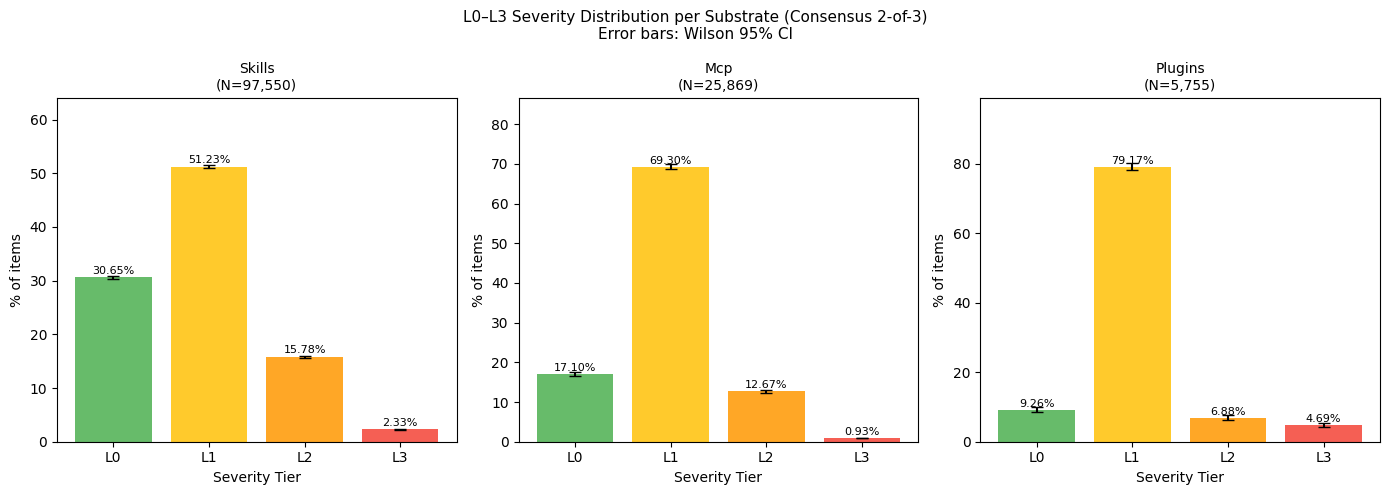

Saved fig1_severity_distribution.png


In [24]:
# --- Figure 1: L0-L3 distribution per substrate (stacked bar) ---
TIER_COLORS = {'L0': '#4CAF50', 'L1': '#FFC107', 'L2': '#FF9800', 'L3': '#F44336'}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, sub in enumerate(SUBSTRATES):
    ax   = axes[i]
    df   = dist_results[sub]
    pcts = [df.loc[t, 'pct'] for t in SEVERITY_ORDER]
    errs = [[df.loc[t, 'pct'] - df.loc[t, 'ci_lo'] for t in SEVERITY_ORDER],
            [df.loc[t, 'ci_hi'] - df.loc[t, 'pct']  for t in SEVERITY_ORDER]]

    bars = ax.bar(SEVERITY_ORDER, pcts,
                  color=[TIER_COLORS[t] for t in SEVERITY_ORDER],
                  yerr=errs, capsize=4, alpha=0.85)

    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{pct:.2f}%', ha='center', va='bottom', fontsize=8)

    ax.set_title(f'{sub.capitalize()}\n(N={len(consensus[sub]):,})', fontsize=10)
    ax.set_xlabel('Severity Tier')
    ax.set_ylabel('% of items')
    ax.set_ylim(0, max(pcts) * 1.25)

fig.suptitle('L0–L3 Severity Distribution per Substrate (Consensus 2-of-3)\n'
             'Error bars: Wilson 95% CI', fontsize=11)
plt.tight_layout()
plt.savefig(CORPUS_ROOT / 'JupyterNotebook' / 'fig1_severity_distribution.png', dpi=150)
plt.show()
print('Saved fig1_severity_distribution.png')

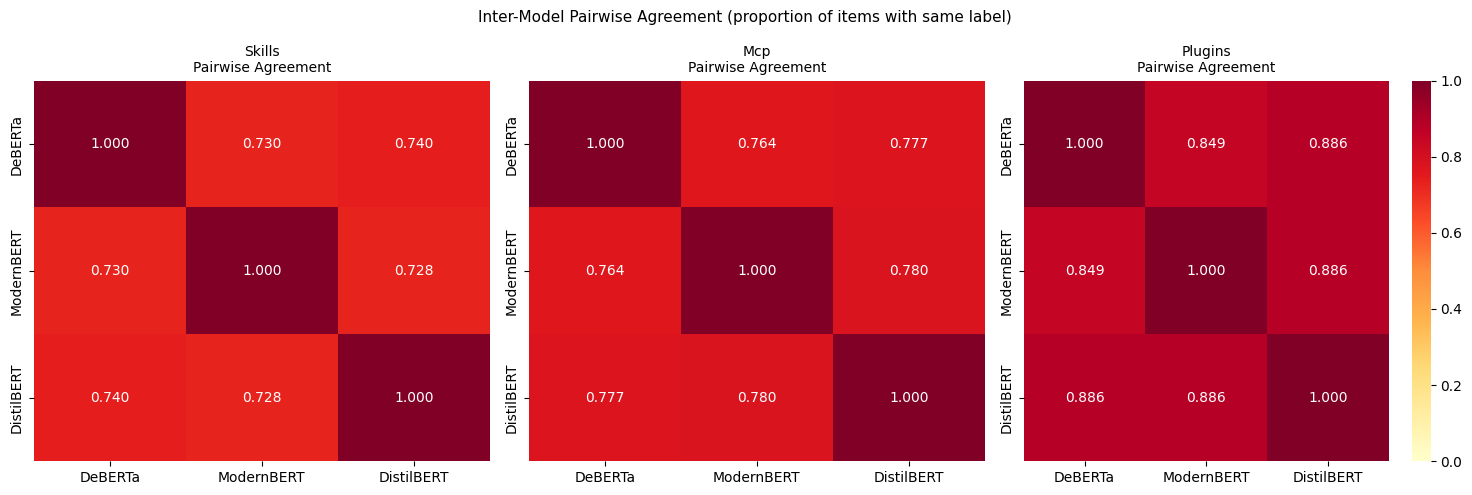

Saved fig2_model_agreement.png


In [25]:
# --- Figure 2: Inter-model agreement heatmap per substrate ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, sub in enumerate(SUBSTRATES):
    df = consensus[sub]
    m_names = list(dfs[sub].keys())
    short_names = ['DeBERTa', 'ModernBERT', 'DistilBERT']
    sev_cols = [f'sev_{mn}' for mn in m_names]

    # Pairwise agreement matrix
    n = len(sev_cols)
    agree_mat = np.zeros((n, n))
    for a in range(n):
        for b in range(n):
            if a == b:
                agree_mat[a, b] = 1.0
            else:
                agree_mat[a, b] = (df[sev_cols[a]] == df[sev_cols[b]]).mean()

    ax = axes[i]
    sns.heatmap(agree_mat, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=short_names, yticklabels=short_names,
                vmin=0, vmax=1, ax=ax, cbar=(i == 2))
    ax.set_title(f'{sub.capitalize()}\nPairwise Agreement', fontsize=10)

fig.suptitle('Inter-Model Pairwise Agreement (proportion of items with same label)',
             fontsize=11)
plt.tight_layout()
plt.savefig(CORPUS_ROOT / 'JupyterNotebook' / 'fig2_model_agreement.png', dpi=150)
plt.show()
print('Saved fig2_model_agreement.png')

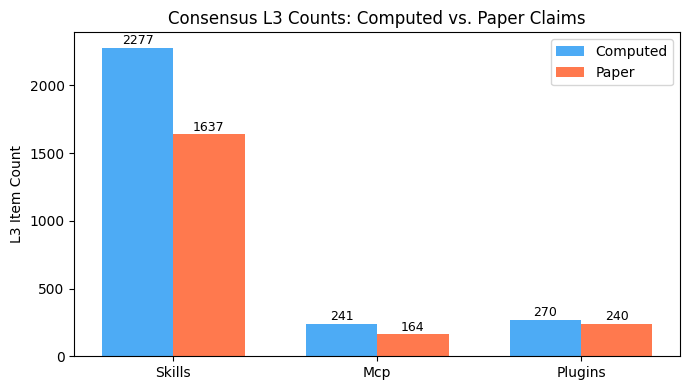

Saved fig3_L3_validation.png


In [26]:
# --- Figure 3: L3 count comparison (computed vs. paper) ---
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(SUBSTRATES))
w = 0.35

computed = [int((consensus[sub]['consensus_severity'] == 'L3').sum()) for sub in SUBSTRATES]
paper    = [paper_L3[sub] for sub in SUBSTRATES]

bars1 = ax.bar(x - w/2, computed, w, label='Computed', color='#2196F3', alpha=0.8)
bars2 = ax.bar(x + w/2, paper,    w, label='Paper',    color='#FF5722', alpha=0.8)

for bar, val in zip(list(bars1) + list(bars2), computed + paper):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in SUBSTRATES])
ax.set_ylabel('L3 Item Count')
ax.set_title('Consensus L3 Counts: Computed vs. Paper Claims')
ax.legend()
plt.tight_layout()
plt.savefig(CORPUS_ROOT / 'JupyterNotebook' / 'fig3_L3_validation.png', dpi=150)
plt.show()
print('Saved fig3_L3_validation.png')

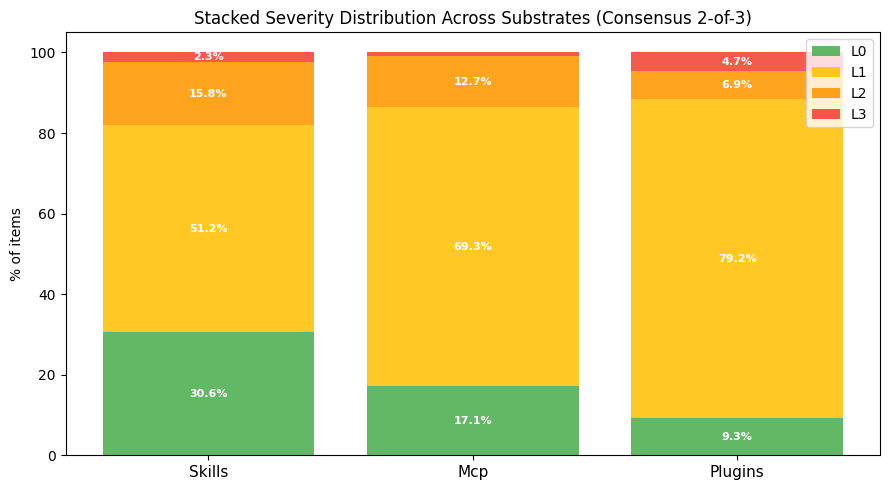

Saved fig4_stacked_distribution.png


In [27]:
# --- Figure 4: Severity distribution stacked 100% bar (all substrates side by side) ---
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(SUBSTRATES))

bottoms = np.zeros(len(SUBSTRATES))
for tier in SEVERITY_ORDER:
    vals = [dist_results[sub].loc[tier, 'pct'] for sub in SUBSTRATES]
    bars = ax.bar(x, vals, bottom=bottoms,
                  color=TIER_COLORS[tier], label=tier, alpha=0.88)
    for bar, v, bot in zip(bars, vals, bottoms):
        if v > 1:
            ax.text(bar.get_x() + bar.get_width()/2, bot + v/2,
                    f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white',
                    fontweight='bold')
    bottoms = bottoms + np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in SUBSTRATES], fontsize=11)
ax.set_ylabel('% of items')
ax.set_ylim(0, 105)
ax.set_title('Stacked Severity Distribution Across Substrates (Consensus 2-of-3)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(CORPUS_ROOT / 'JupyterNotebook' / 'fig4_stacked_distribution.png', dpi=150)
plt.show()
print('Saved fig4_stacked_distribution.png')

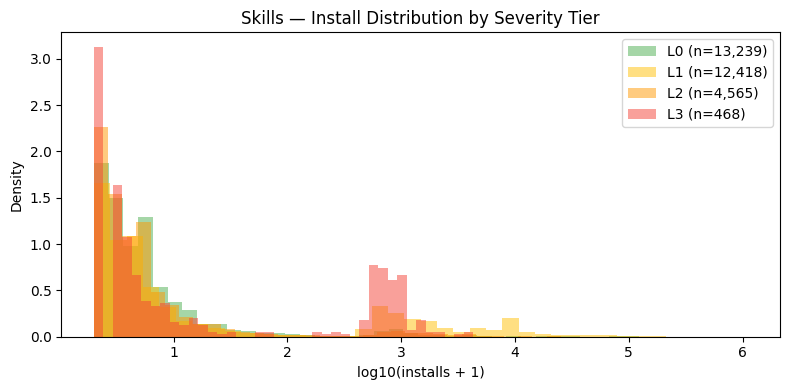

Saved fig5_installs_by_tier.png


In [28]:
# --- Figure 5: Log-scale installs distribution L0 vs L3 (skills only) ---
con_df  = consensus['skills'][['slug', 'consensus_severity']]
heur_df = heuristic['skills'][['slug', 'installs']]
merged  = con_df.merge(heur_df, on='slug', how='inner')
merged  = merged[merged['installs'] > 0]

fig, ax = plt.subplots(figsize=(8, 4))
for tier, color in TIER_COLORS.items():
    subset = merged[merged['consensus_severity'] == tier]['installs']
    if len(subset) > 0:
        ax.hist(np.log10(subset + 1), bins=40, alpha=0.5,
                color=color, label=f'{tier} (n={len(subset):,})', density=True)

ax.set_xlabel('log10(installs + 1)')
ax.set_ylabel('Density')
ax.set_title('Skills — Install Distribution by Severity Tier')
ax.legend()
plt.tight_layout()
plt.savefig(CORPUS_ROOT / 'JupyterNotebook' / 'fig5_installs_by_tier.png', dpi=150)
plt.show()
print('Saved fig5_installs_by_tier.png')

## 12. Findings Summary

In [30]:
print('=' * 65)
print('TRUST AUDIT CORPUS — VALIDATION SUMMARY')
print('=' * 65)

print('\n[1] DATASET SIZE')
for sub in SUBSTRATES:
    n = len(consensus[sub])
    print(f'   {sub}: {n:,} items in consensus set')

print('\n[2] L3 PREVALENCE (consensus 2-of-3)')
for sub in SUBSTRATES:
    n_L3  = (consensus[sub]['consensus_severity'] == 'L3').sum()
    total = len(consensus[sub])
    p, lo, hi = wilson_ci(n_L3, total)
    expected  = paper_L3[sub]
    match = 'MATCH' if n_L3 == expected else f'DIFF {n_L3 - expected:+d}'
    print(f'   {sub}: {n_L3:,}/{total:,} = {p*100:.2f}% '
          f'[{lo*100:.2f},{hi*100:.2f}] | paper {expected:,} → {match}')

print('\n[3] DEFENDER GOLD RECALL')
for sub in SUBSTRATES:
    con_df = consensus[sub]
    gold   = con_df[con_df['defender_positive'] == True]
    if len(gold) == 0:
        print(f'   {sub}: no gold items')
        continue
    recall = (gold['consensus_severity'] == 'L3').sum() / len(gold)
    print(f'   {sub}: {recall:.2%} ({int(recall*len(gold))}/{len(gold)})')

print('\n[4] HEURISTIC ANY-FLAG PREVALENCE')
for sub in SUBSTRATES:
    df = heuristic[sub]
    k  = df['any_flag'].sum()
    p, lo, hi = wilson_ci(k, len(df))
    print(f'   {sub}: {k:,}/{len(df):,} = {p*100:.2f}% [{lo*100:.2f},{hi*100:.2f}]')

print('\n[5] CHI-SQUARED (cross-substrate independence)')
# Recompute
contingency = []
for sub in SUBSTRATES:
    vc = consensus[sub]['consensus_severity'].value_counts()
    contingency.append([vc.get(t, 0) for t in SEVERITY_ORDER])
chi2, p_chi, dof, _ = chi2_contingency(np.array(contingency))
print(f'   chi2={chi2:.2f}, dof={dof}, p={p_chi:.2e} → {"SIGNIFICANT" if p_chi < 0.001 else "not sig"}')

print('\n[6] TRUST SIGNAL CORRELATIONS (Spearman rho)')
for sub in SUBSTRATES:
    print(f'   {sub}:')
    for sig, (rho, pval) in corr_results.get(sub, {}).items():
        print(f'     rho({sig:<22s}) = {rho:+.4f}  p={pval:.2e}')

print('\n[7] CROSS-DATASET INTEGRITY (local vs. from_lab_pc)')
for sub in SUBSTRATES:
    for model in MODELS:
        if model not in lab_dfs.get(sub, {}):
            continue
        local = dfs[sub][model][['slug', 'severity']].rename(columns={'severity': 'sl'})
        lab   = lab_dfs[sub][model][['slug', 'severity']].rename(columns={'severity': 'la'})
        merged = local.merge(lab, on='slug', how='inner')
        match_pct = (merged['sl'] == merged['la']).mean() * 100
        print(f'   {sub}/{model}: {match_pct:.4f}% agreement')

print('\n' + '=' * 65)

TRUST AUDIT CORPUS — VALIDATION SUMMARY

[1] DATASET SIZE
   skills: 97,550 items in consensus set
   mcp: 25,869 items in consensus set
   plugins: 5,755 items in consensus set

[2] L3 PREVALENCE (consensus 2-of-3)
   skills: 2,277/97,550 = 2.33% [2.24,2.43] | paper 1,637 → DIFF +640
   mcp: 241/25,869 = 0.93% [0.82,1.06] | paper 164 → DIFF +77
   plugins: 270/5,755 = 4.69% [4.17,5.27] | paper 240 → DIFF +30

[3] DEFENDER GOLD RECALL
   skills: 100.00% (51/51)
   mcp: no gold items
   plugins: no gold items

[4] HEURISTIC ANY-FLAG PREVALENCE
   skills: 7,509/93,735 = 8.01% [7.84,8.19]
   mcp: 0/21,355 = 0.00% [0.00,0.02]
   plugins: 0/2,629 = 0.00% [0.00,0.15]

[5] CHI-SQUARED (cross-substrate independence)
   chi2=4605.92, dof=6, p=0.00e+00 → SIGNIFICANT

[6] TRUST SIGNAL CORRELATIONS (Spearman rho)
   skills:
     rho(stars                 ) = -0.0672  p=3.39e-94
     rho(installs              ) = -0.1368  p=0.00e+00
     rho(official_badge_int    ) = +nan  p=nan
   mcp:
     rho(st